# Overfitting in a Backtest: In-Sample Selection and Out-of-Sample Collapse

## Objective

This notebook demonstrates a specific form of backtest overfitting:

> When many useless strategy configurations are tested, the configuration with the best in-sample performance can look profitable purely by chance. Its performance usually collapses on untouched out-of-sample data.

The experiment deliberately uses:

- returns with **zero expected return**;
- signals containing **no predictive information**;
- a chronological in-sample/out-of-sample split;
- the same selected strategy configuration in both periods.

Therefore, any strong in-sample result is a false discovery created by selection over noise.

## 1. Research design

For each simulated experiment:

1. Generate daily asset returns with mean zero.
2. Generate many independent random signal series.
3. Convert each signal into a long/short position.
4. Evaluate every candidate strategy in-sample.
5. Select the candidate with the highest in-sample Sharpe ratio.
6. Evaluate that **same candidate** out-of-sample.
7. Repeat the process many times.

The selection rule is

$$
m^* = \arg\max_m \widehat{SR}_{m,IS},
$$

followed by evaluation of

$$
\widehat{SR}_{m^*,OOS}.
$$

Selecting a different winner in the OOS period would contaminate the holdout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
TRADING_DAYS = 252
N_IS = 756
N_OOS = 756
N_REPETITIONS = 100

rng = np.random.default_rng(SEED)

## 2. Helper functions

The annualised Sharpe ratio is

$$
\widehat{SR}=\frac{\bar r}{s_r}\sqrt{252},
$$

where $\bar r$ is mean daily return and $s_r$ is sample daily volatility.

In [2]:
def annualized_sharpe(returns: np.ndarray) -> float:
    """Calculate annualised Sharpe ratio from one-dimensional daily returns."""
    returns = np.asarray(returns, dtype=float)
    returns = returns[np.isfinite(returns)]
    if returns.size < 2:
        return np.nan
    volatility = returns.std(ddof=1)
    if volatility == 0:
        return np.nan
    return returns.mean() / volatility * np.sqrt(TRADING_DAYS)


def columnwise_sharpe(strategy_returns: np.ndarray) -> np.ndarray:
    """Calculate an annualised Sharpe ratio for every strategy column."""
    means = strategy_returns.mean(axis=0)
    vols = strategy_returns.std(axis=0, ddof=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        return means / vols * np.sqrt(TRADING_DAYS)


def equity_curve(returns: np.ndarray) -> np.ndarray:
    """Convert simple periodic returns into a cumulative equity curve."""
    return np.cumprod(1.0 + np.asarray(returns, dtype=float))

## 3. One simulated strategy tournament

Each candidate receives a random feature

$$
x_{m,t}\sim N(0,1),
$$

and takes the delayed position

$$
w_{m,t}=\operatorname{sign}(x_{m,t-1}).
$$

The delay prevents same-period look-ahead. Since signals and returns are independent, every strategy has true expected return equal to zero.

In [3]:
N_CANDIDATES = 300
n_total = N_IS + N_OOS

asset_returns = rng.normal(0.0, 0.01, size=n_total)
random_features = rng.normal(0.0, 1.0, size=(n_total, N_CANDIDATES))

positions = np.sign(random_features)
positions = np.vstack([np.zeros((1, N_CANDIDATES)), positions[:-1]])
strategy_returns = positions * asset_returns[:, None]

returns_is = strategy_returns[:N_IS]
returns_oos = strategy_returns[N_IS:]
sharpes_is = columnwise_sharpe(returns_is)
best_strategy_id = int(np.nanargmax(sharpes_is))

best_is_returns = returns_is[:, best_strategy_id]
best_oos_returns = returns_oos[:, best_strategy_id]

summary_one_run = pd.Series({
    "Candidates tested": N_CANDIDATES,
    "Selected strategy ID": best_strategy_id,
    "Best in-sample Sharpe": annualized_sharpe(best_is_returns),
    "Same strategy OOS Sharpe": annualized_sharpe(best_oos_returns),
    "Sharpe collapse": annualized_sharpe(best_is_returns) - annualized_sharpe(best_oos_returns),
})
summary_one_run

Candidates tested           300.000000
Selected strategy ID        213.000000
Best in-sample Sharpe         2.083743
Same strategy OOS Sharpe      0.213131
Sharpe collapse               1.870611
dtype: float64

### Interpretation

The selected strategy won a tournament among many noise strategies. Its in-sample Sharpe is conditional on being selected as the maximum, so it is optimistically biased.

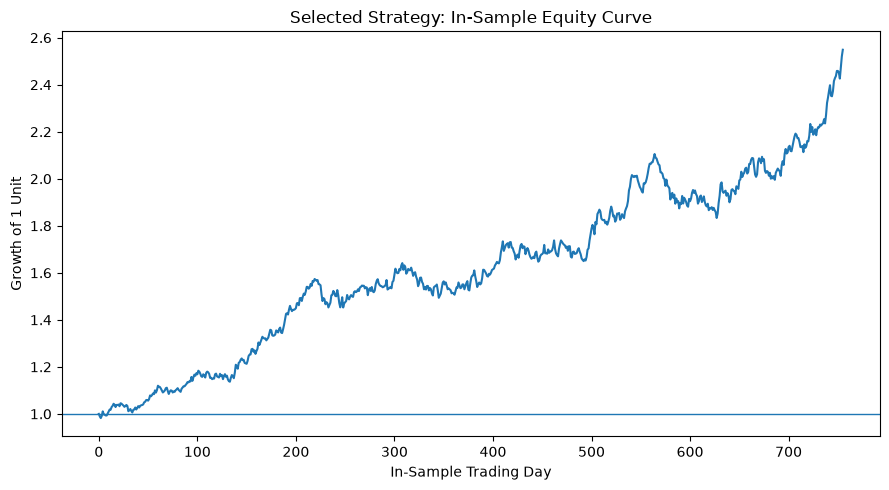

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(equity_curve(best_is_returns))
plt.axhline(1.0, linewidth=1)
plt.title("Selected Strategy: In-Sample Equity Curve")
plt.xlabel("In-Sample Trading Day")
plt.ylabel("Growth of 1 Unit")
plt.tight_layout()
plt.show()

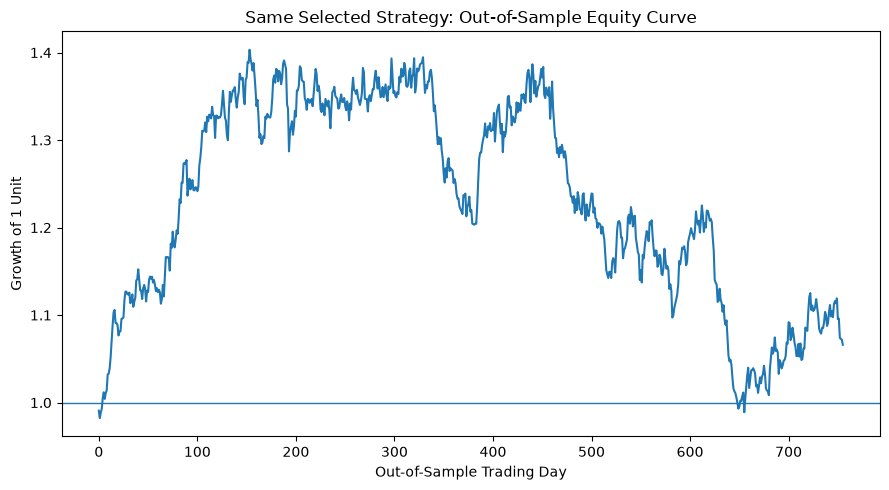

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(equity_curve(best_oos_returns))
plt.axhline(1.0, linewidth=1)
plt.title("Same Selected Strategy: Out-of-Sample Equity Curve")
plt.xlabel("Out-of-Sample Trading Day")
plt.ylabel("Growth of 1 Unit")
plt.tight_layout()
plt.show()

## 4. Monte Carlo experiment: increase the search space

We repeat the experiment for different numbers of candidate strategies.

Expected result:

$$
M\uparrow \Rightarrow \mathbb{E}[\max_m \widehat{SR}_{m,IS}]\uparrow,
$$

while

$$
\mathbb{E}[\widehat{SR}_{m^*,OOS}]\approx 0.
$$

In [6]:
def run_selection_experiment(n_candidates: int, rng: np.random.Generator) -> tuple[float, float]:
    """Select the best noise strategy IS and evaluate the same strategy OOS."""
    n_total = N_IS + N_OOS
    asset_returns = rng.normal(0.0, 0.01, size=n_total)
    features = rng.normal(0.0, 1.0, size=(n_total, n_candidates))
    positions = np.sign(features)
    positions = np.vstack([np.zeros((1, n_candidates)), positions[:-1]])
    candidate_returns = positions * asset_returns[:, None]

    candidate_is = candidate_returns[:N_IS]
    candidate_oos = candidate_returns[N_IS:]
    is_sharpes = columnwise_sharpe(candidate_is)
    selected_id = int(np.nanargmax(is_sharpes))

    return float(is_sharpes[selected_id]), annualized_sharpe(candidate_oos[:, selected_id])


candidate_counts = [1, 5, 20, 100, 300]
records = []
simulation_rng = np.random.default_rng(SEED + 1)

for n_candidates in candidate_counts:
    for repetition in range(N_REPETITIONS):
        is_sharpe, oos_sharpe = run_selection_experiment(n_candidates, simulation_rng)
        records.append({
            "n_candidates": n_candidates,
            "repetition": repetition,
            "selected_is_sharpe": is_sharpe,
            "selected_oos_sharpe": oos_sharpe,
        })

simulation_results = pd.DataFrame(records)
monte_carlo_summary = simulation_results.groupby("n_candidates").agg(
    mean_selected_is_sharpe=("selected_is_sharpe", "mean"),
    mean_selected_oos_sharpe=("selected_oos_sharpe", "mean"),
    median_selected_oos_sharpe=("selected_oos_sharpe", "median"),
    probability_oos_negative=("selected_oos_sharpe", lambda x: (x < 0).mean()),
)
monte_carlo_summary

,mean_selected_is_sharpe,mean_selected_oos_sharpe,median_selected_oos_sharpe,probability_oos_negative
n_candidates,,,,
1,0.035619,-0.018069,-0.023970,0.52
5,0.781602,0.033078,0.034820,0.49
20,1.114025,0.031419,-0.003071,0.50
100,1.463013,-0.021310,-0.099892,0.55
300,1.678356,0.069545,0.131005,0.39


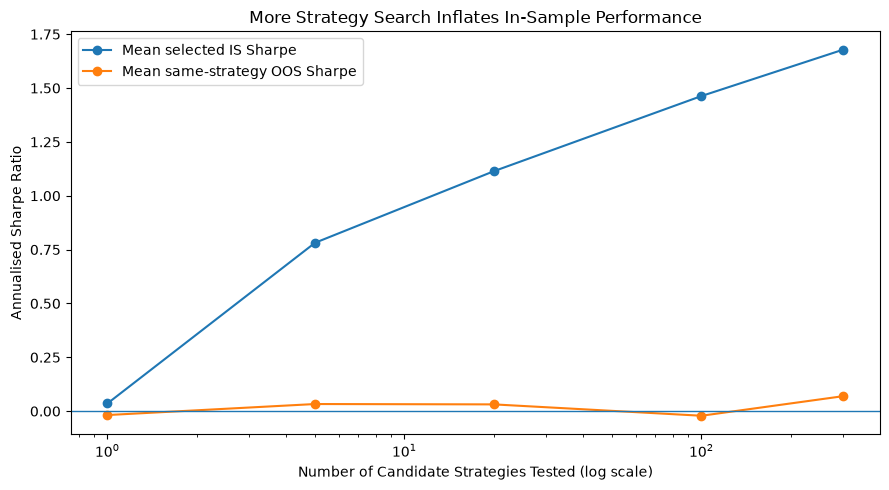

In [7]:
plot_data = monte_carlo_summary.reset_index()

plt.figure(figsize=(9, 5))
plt.plot(plot_data["n_candidates"], plot_data["mean_selected_is_sharpe"], marker="o", label="Mean selected IS Sharpe")
plt.plot(plot_data["n_candidates"], plot_data["mean_selected_oos_sharpe"], marker="o", label="Mean same-strategy OOS Sharpe")
plt.axhline(0.0, linewidth=1)
plt.xscale("log")
plt.title("More Strategy Search Inflates In-Sample Performance")
plt.xlabel("Number of Candidate Strategies Tested (log scale)")
plt.ylabel("Annualised Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Mathematical interpretation

Write the estimated performance of candidate $m$ as

$$
\widehat{SR}_m = SR_m + \varepsilon_m.
$$

Here every true Sharpe is $SR_m=0$. Selection chooses

$$
m^*=\arg\max_m \widehat{SR}_m,
$$

which tends to select an unusually positive error $\varepsilon_m$. That favourable error does not persist on independent data. This is the winner's curse and model-selection overfitting.

## 6. Optional implementation stress: transaction costs

Net return is modelled as

$$
r^{net}_t=r^{gross}_t-c|w_t-w_{t-1}|.
$$

Because random strategies trade frequently and possess no gross edge, positive costs make expected net performance negative.

In [8]:
cost_per_unit_turnover = 0.0001  # 1 basis point
selected_positions_oos = positions[N_IS:, best_strategy_id]
turnover_oos = np.abs(np.diff(selected_positions_oos, prepend=0.0))
best_oos_returns_net = best_oos_returns - cost_per_unit_turnover * turnover_oos

pd.Series({
    "OOS gross Sharpe": annualized_sharpe(best_oos_returns),
    "OOS net Sharpe": annualized_sharpe(best_oos_returns_net),
    "Average daily turnover": turnover_oos.mean(),
    "Total estimated cost": (cost_per_unit_turnover * turnover_oos).sum(),
})

OOS gross Sharpe          0.213131
OOS net Sharpe            0.061424
Average daily turnover    0.966931
Total estimated cost      0.073100
dtype: float64

## 7. Invalid procedures

### Selecting a new OOS winner

```python
best_oos_id = np.argmax(oos_sharpes)
```

This uses the holdout for model selection and destroys its independence.

### Modifying the strategy after observing OOS

Changing features, thresholds, or candidate counts after inspecting OOS performance converts the test sample into validation data.

### Same-period signal and return

```python
strategy_returns = signal * returns
```

This is invalid when the signal is only known at the end of the same period. A shift or realistic execution rule is required.

### Reporting only the winner

The report must disclose the number of candidates tested, the selection rule, the holdout design, costs, and all material researcher choices.

## 8. Final conclusion

This experiment contains no predictive signal. Any strong in-sample performance is known to be false.

$$
\text{larger search space}
\rightarrow
\text{more favourable noise selected}
\rightarrow
\text{higher apparent IS Sharpe}
\rightarrow
\text{OOS collapse}.
$$

The correct lesson is not that optimisation is forbidden. It is that optimisation must be evaluated as part of the model:

- bound and disclose the search space;
- select only on training and validation data;
- preserve a locked chronological holdout;
- evaluate the same selected configuration OOS;
- include realistic transaction costs;
- do not retune after opening the holdout.

## 9. Exercises

1. Increase the candidate count from 300 to 3,000.
2. Increase the in-sample length and assess whether selection noise falls.
3. Raise costs from 1 to 5 basis points.
4. Replace random signals with many moving-average rules applied to a random-walk price.
5. Add a separate validation period before the final test period.
6. Save every configuration to an experiment ledger rather than reporting only the winner.